In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')


In [2]:
def funcion(posicion, schedule):
    return posicion - schedule * np.tanh(posicion * schedule / (1 - schedule**2))

def derivada(posicion, schedule):
    return 1 - schedule**2 / (1 - schedule**2) * (1 - np.tanh(posicion * schedule / (1 - schedule**2)))

In [10]:
schedule = np.linspace(0.1,1,100)
posicion = np.ones(100)

for i in range(10000):
    nueva_posicion = posicion - funcion(posicion,schedule)/derivada(posicion,schedule)
    posicion = nueva_posicion


/tmp/ipykernel_21199/3221838135.py:2: RuntimeWarning: divide by zero encountered in divide
  return posicion - schedule * np.tanh(posicion * schedule / (1 - schedule**2))
/tmp/ipykernel_21199/3221838135.py:5: RuntimeWarning: divide by zero encountered in divide
  return 1 - schedule**2 / (1 - schedule**2) * (1 - np.tanh(posicion * schedule / (1 - schedule**2)))
/tmp/ipykernel_21199/3221838135.py:5: RuntimeWarning: invalid value encountered in multiply
  return 1 - schedule**2 / (1 - schedule**2) * (1 - np.tanh(posicion * schedule / (1 - schedule**2)))


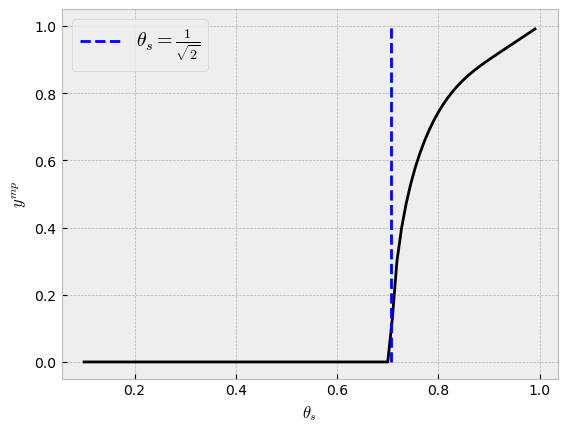

In [26]:
fig1, ax1 = plt.subplots()

ax1.set_xlabel(r'$\theta_s$')
ax1.set_ylabel(r'$y^{m p}$')

ax1.plot(schedule, posicion, color='k')
ax1.vlines(x=1/np.sqrt(2), ymin=0, ymax=1, ls='dashed', color='blue',
            label=r'$\theta_s=\frac{1}{\sqrt{2}}$')

ax1.legend(fontsize='x-large')

fig1.savefig('ymp.pdf')

In [27]:
def suceptibility(theta):
    delta = 1 - theta**2

    first_bracket = theta**2/delta - 1

    second_bracket = 3 * delta**2 / theta**2 * first_bracket

    third_bracket = 1 - second_bracket**2

    return 1  / (theta/delta - 1/(theta*third_bracket))

/tmp/ipykernel_21199/1852674692.py:4: RuntimeWarning: divide by zero encountered in divide
  first_bracket = theta**2/delta - 1
/tmp/ipykernel_21199/1852674692.py:6: RuntimeWarning: invalid value encountered in multiply
  second_bracket = 3 * delta**2 / theta**2 * first_bracket
/tmp/ipykernel_21199/1852674692.py:10: RuntimeWarning: divide by zero encountered in divide
  return 1  / (theta/delta - 1/(theta*third_bracket))


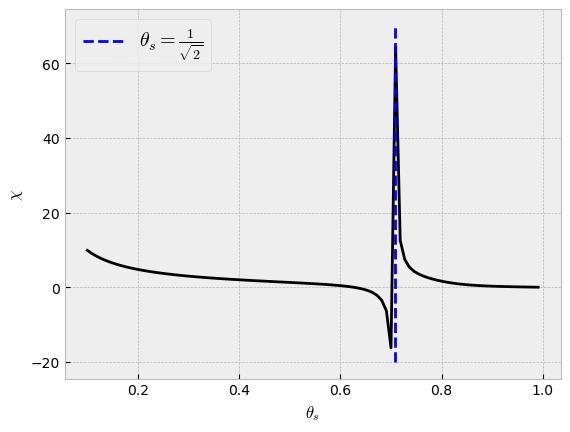

In [37]:
fig2, ax2 = plt.subplots()

ax2.set_xlabel(r'$\theta_s$')
ax2.set_ylabel(r'$\chi$')

ax2.plot(schedule,suceptibility(schedule), color='k')
ax2.vlines(x=1/np.sqrt(2), ymin=-20, ymax=70, ls='dashed', color='blue',
            label=r'$\theta_s=\frac{1}{\sqrt{2}}$')

ax2.legend(fontsize='x-large', loc='upper left')

fig2.savefig('suceptibility.pdf')
